In [5]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)
# See what's in the downloaded path
print(os.listdir(path))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification
['seg_train', 'seg_pred', 'seg_test']


In [6]:
TRAIN_DIR = '/kaggle/input/intel-image-classification/seg_train/seg_train'
TEST_DIR = '/kaggle/input/intel-image-classification/seg_test/seg_test'

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train classes: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Test classes: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Normalise pixel values to [0,1] and set 80/20 split
datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [8]:
# Training dara
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

Found 11230 images belonging to 6 classes.


In [9]:
# Testing data
val_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 2804 images belonging to 6 classes.


In [10]:
# Validating data
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [11]:
NUM_CLASSES = 6 # As stated in the beginning

print("Dataset Summary")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {list(train_generator.class_indices.keys())}")

Dataset Summary
Training samples: 11230
Validation samples: 2804
Test samples: 3000
Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Task 1

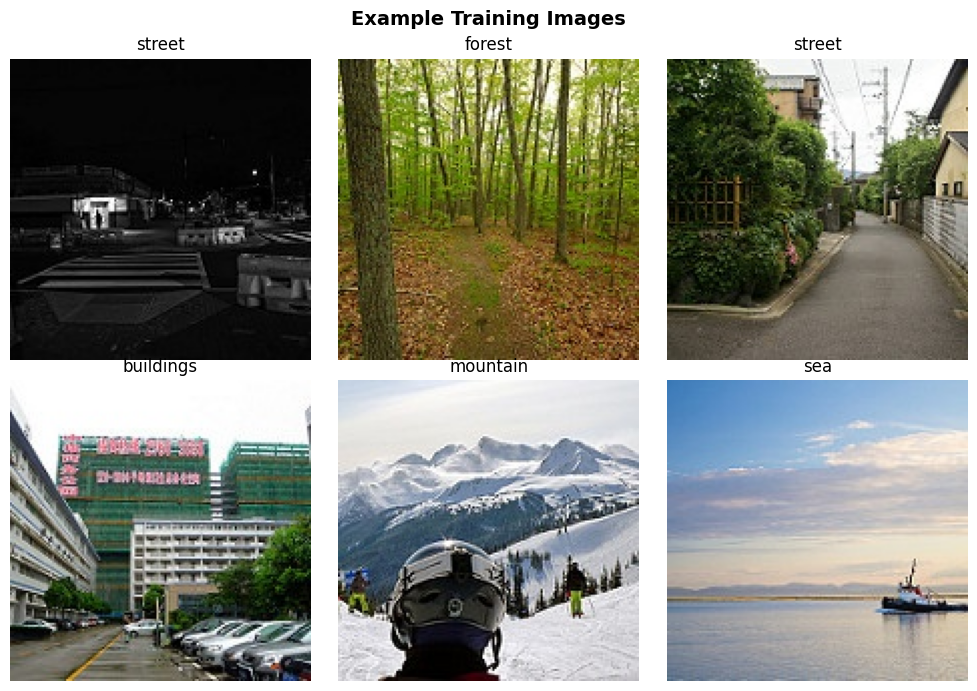

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Grab a batch of images
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle('Example Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(class_names[np.argmax(labels[i])])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Task 2

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Conv block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Flatten & Dense head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
], name='Basic_CNN')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,431,494 (85.57 MB)

 Trainable params: 22,431,494 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 207ms/step - accuracy: 0.6189 - loss: 1.3727 - val_accuracy: 0.7140 - val_loss: 0.8223
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.7999 - loss: 0.5795 - val_accuracy: 0.6669 - val_loss: 0.9012
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.8983 - loss: 0.3229 - val_accuracy: 0.7457 - val_loss: 0.7511
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9539 - loss: 0.1609 - val_accuracy: 0.7254 - val_loss: 0.9006
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9706 - loss: 0.1166 - val_accuracy: 0.7593 - val_loss: 0.9144
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9869 - loss: 0.0624 - val_accuracy: 0.7429 - val_loss: 1.0228
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9901 - loss: 0.0491 - val_accuracy: 0.6922 - val_loss: 1.3155
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9940 - loss: 0.0335 -

In [16]:
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTask 2 Test Accuracy: {accuracy*100:.2f}%')

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.6680 - loss: 2.1481

Task 2 Test Accuracy: 66.80%


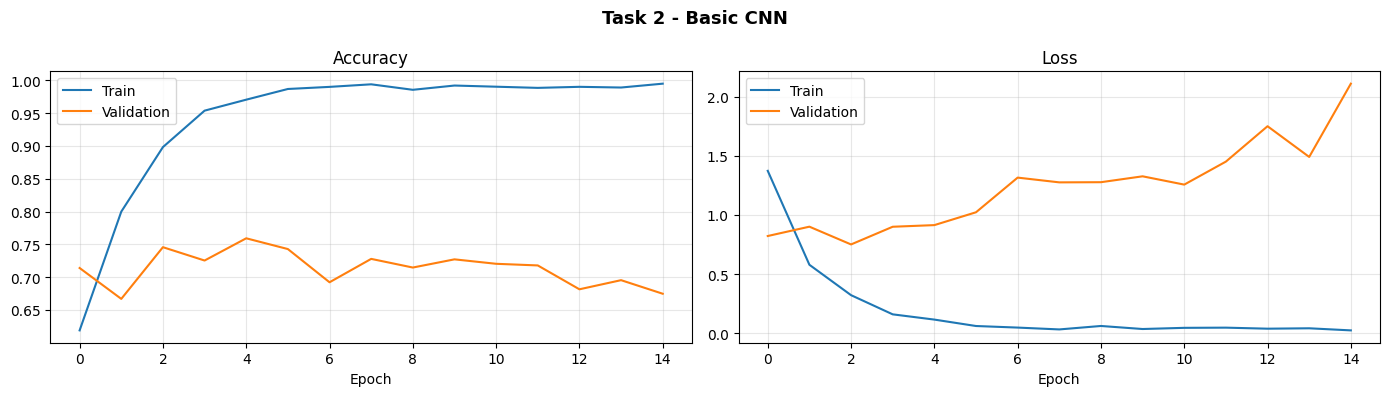

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 2 - Basic CNN', fontsize=13, fontweight='bold')

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3


In [18]:
model3 = models.Sequential([
    # Conv block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Dense head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(6, activation='softmax')
], name='Deeper_CNN')

model3.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,758,054 (41.04 MB)

 Trainable params: 10,758,054 (41.04 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - accuracy: 0.6102 - loss: 0.9801 - val_accuracy: 0.7479 - val_loss: 0.6735
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.7533 - loss: 0.6493 - val_accuracy: 0.7899 - val_loss: 0.5786
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8264 - loss: 0.4836 - val_accuracy: 0.7867 - val_loss: 0.5926
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8781 - loss: 0.3430 - val_accuracy: 0.7946 - val_loss: 0.5737
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9209 - loss: 0.2225 - val_accuracy: 0.8088 - val_loss: 0.6909
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9500 - loss: 0.1435 - val_accuracy: 0.8128 - val_loss: 0.8475
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.9698 - loss: 0.0891 - val_accuracy: 0.7953 - val_loss: 1.0098
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9714 - loss: 0.0870 -

In [20]:
loss3, accuracy3 = model3.evaluate(test_generator, verbose=1)
print(f'\nTask 3 Test Accuracy: {accuracy3*100:.2f}%')

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7737 - loss: 1.2926

Task 3 Test Accuracy: 77.37%


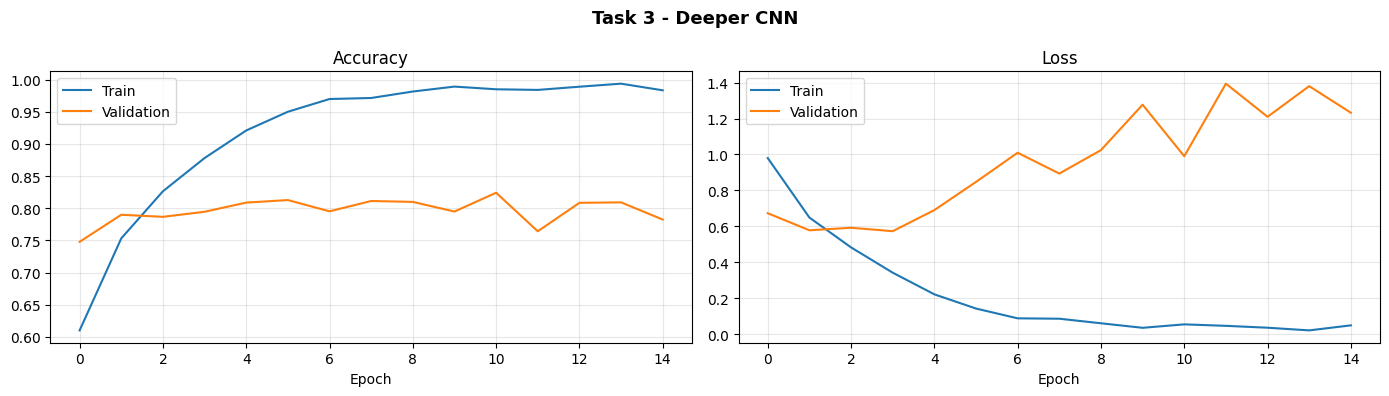

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 3 - Deeper CNN', fontsize=13, fontweight='bold')

ax1.plot(history3.history['accuracy'], label='Train')
ax1.plot(history3.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history3.history['loss'], label='Train')
ax2.plot(history3.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 4

In [22]:
aug_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    horizontal_flip=True,      # randomly flip images left/right
    rotation_range=20,         # randomly rotate up to 20 degrees
    zoom_range=0.2,            # randomly zoom in/out 20%
    brightness_range=[0.8, 1.2], # randomly adjust brightness
    width_shift_range=0.1,     # randomly shift horizontally
    height_shift_range=0.1     # randomly shift vertically
)

In [23]:
aug_train_generator = aug_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

aug_val_generator = aug_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


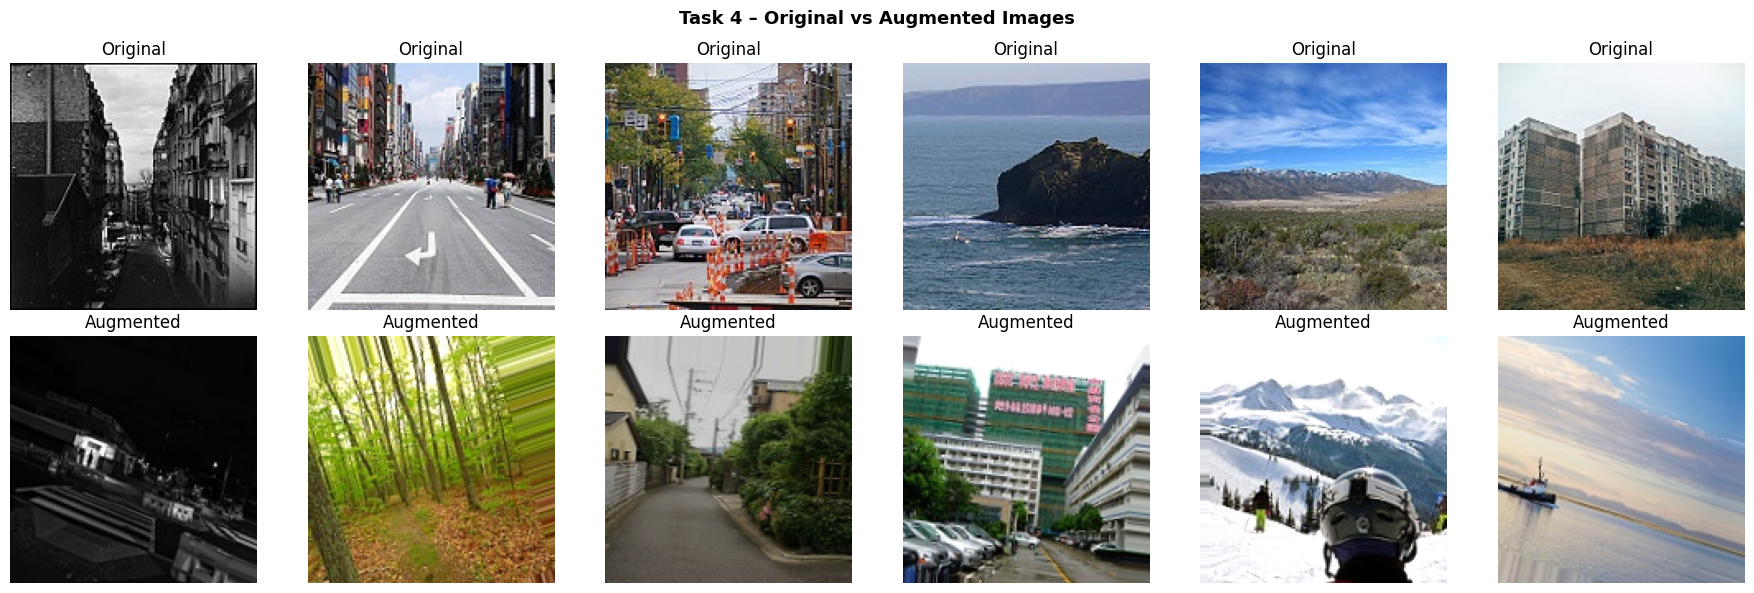

In [24]:
aug_images, _ = next(aug_train_generator)
orig_images, _ = next(train_generator)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Task 4 – Original vs Augmented Images', fontsize=13, fontweight='bold')

for i in range(6):
    axes[0, i].imshow(orig_images[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(aug_images[i])
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [25]:
model4 = models.Sequential([
    # Conv block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Dense head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(6, activation='softmax')
], name='Augmented_CNN')

model4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(
    aug_train_generator,
    epochs=20,
    validation_data=aug_val_generator,
    verbose=1
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 119s 329ms/step - accuracy: 0.5599 - loss: 1.0843 - val_accuracy: 0.6334 - val_loss: 0.9066
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 320ms/step - accuracy: 0.6671 - loss: 0.8499 - val_accuracy: 0.7147 - val_loss: 0.7496
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 315ms/step - accuracy: 0.7330 - loss: 0.7165 - val_accuracy: 0.7675 - val_loss: 0.6361
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 313ms/step - accuracy: 0.7522 - loss: 0.6697 - val_accuracy: 0.7689 - val_loss: 0.6293
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 314ms/step - accuracy: 0.7790 - loss: 0.6034 - val_accuracy: 0.7985 - val_loss: 0.5451
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.7956 - loss: 0.5626 - val_accuracy: 0.8174 - val_loss: 0.5303
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 318ms/step - accuracy: 0.8082 - loss: 0.5314 - val_accuracy: 0.8170 - val_loss: 0.5153
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 113s 321ms/step - accuracy: 0.8170 -

In [26]:
loss4, accuracy4 = model4.evaluate(test_generator, verbose=1)
print(f'\nTask 4 Test Accuracy: {accuracy4*100:.2f}%')

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8610 - loss: 0.3877

Task 4 Test Accuracy: 86.10%


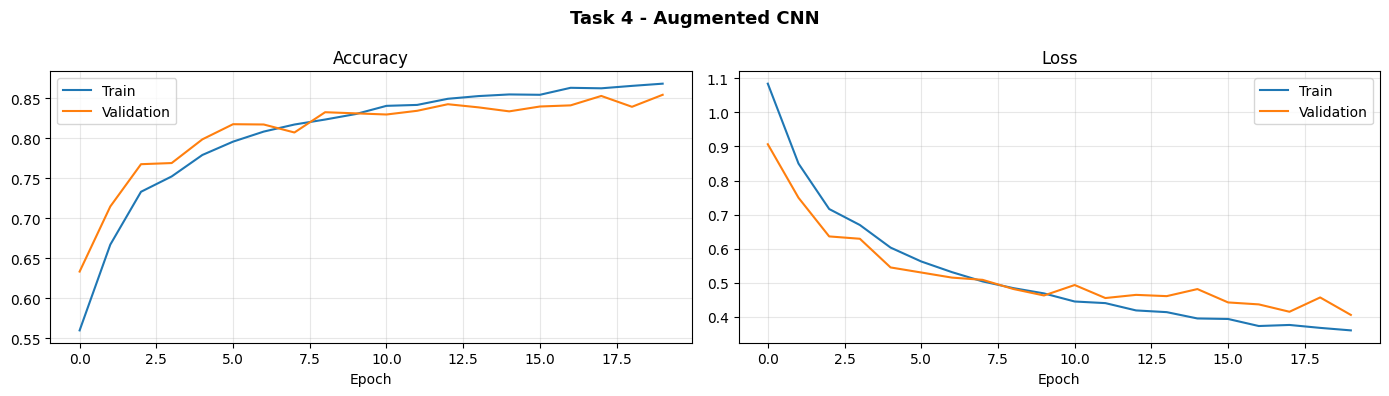

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 4 - Augmented CNN', fontsize=13, fontweight='bold')

ax1.plot(history4.history['accuracy'], label='Train')
ax1.plot(history4.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history4.history['loss'], label='Train')
ax2.plot(history4.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 5

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

model5 = models.Sequential([
    # Conv block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # switch off 25% of neurons randomly

    # Conv block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Dense head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # switch off 50% before output
    layers.Dense(6, activation='softmax')
], name='Regularised_CNN')

model5.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model5.summary()

Model: "Regularised_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,758,054 (41.04 MB)

 Trainable params: 10,758,054 (41.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', # watch the validation loss
    patience=5, # stop if no improvement for 5 epochs
    restore_best_weights=True, # go back to the best version
    verbose=1
)

history5 = model5.fit(
    aug_train_generator,
    epochs=40, # high ceiling, early stopping will cut it short
    validation_data=aug_val_generator,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 123s 331ms/step - accuracy: 0.5115 - loss: 1.2262 - val_accuracy: 0.5988 - val_loss: 1.0401
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.6070 - loss: 0.9827 - val_accuracy: 0.6512 - val_loss: 0.8964
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 320ms/step - accuracy: 0.6600 - loss: 0.8869 - val_accuracy: 0.6994 - val_loss: 0.8054
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 320ms/step - accuracy: 0.6974 - loss: 0.8093 - val_accuracy: 0.7364 - val_loss: 0.7206
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 318ms/step - accuracy: 0.7217 - loss: 0.7578 - val_accuracy: 0.7496 - val_loss: 0.6764
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 315ms/step - accuracy: 0.7440 - loss: 0.7082 - val_accuracy: 0.7825 - val_loss: 0.6060
Epoch 7/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.7511 - loss: 0.6803 - val_accuracy: 0.7867 - val_loss: 0.6022
Epoch 8/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.7721 -

In [ ]:
loss5, accuracy5 = model5.evaluate(test_generator, verbose=1)
print(f'\nTask 5 Test Accuracy: {accuracy5*100:.2f}%')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 5 - Regularised CNN', fontsize=13, fontweight='bold')

ax1.plot(history5.history['accuracy'], label='Train')
ax1.plot(history5.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history5.history['loss'], label='Train')
ax2.plot(history5.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
results = {
    'Task 2\nBasic CNN': 69.83,
    'Task 3\nDeeper CNN': 76.17,
    'Task 4\nAugmentation': 86.00,
    'Task 5\nRegularisation': 85.67
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(results.keys(), results.values(), color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison – Tasks 2 to 5', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()